In [1]:
import warnings

import pandas as pd
import muon as mu

from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

from dextrademixer.model import DextraDemixer
from dextrademixer.utils import calculate_metrics

/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/Users/yang.an/PhD/DextraDemixer/dextrademixer/model/Dextrademixer.py:51: SyntaxWarning: invalid escape sequence '\i'
  A read count matrix ***$X_{ij}\in \mathbb{N}$*** approximating the avidity of $i\in N$ T cell for the $j\in M$
/Users/yang.an/PhD/DextraDemixer/dextrademixer/model/Dextrademixer.py:367: SyntaxWarning: invalid escape sequence '\('
  Given posterior draws of signal probabilities \(p_i^{(s)}\), this method computes


In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Dataset configs
F_IN = 'data/example_data.h5mu'  # path to file
GEX_KEY = 'gex'  # name of modality in mudata where the multimer data is stored, e.g., mdata.mod[GEX_KEY]
PMHC_KEY = 'pmhc1'  # key of pMHC of choice in mudata.mod[GEX_KEY].var
AIRR_KEY = 'airr'  # name of TCR/AIRR modality in mudata.mod
CLONE_KEY = 'clone_id'  # key of clone_id in mudata.mod[AIRR_KEY].var
LABEL_KEY = 'is_binder'  # key of label in mudata.mod[GEX_KEY].var, only used for evaluation, not needed for inference only

# Model configs
MODEL_CONFIG = 'DextraDemixer+clone'  # ['DextraDemixer', 'DextraDemixer+neg.', 'DextraDemixer+clone', 'DextraDemixer+neg.+clone']
NEG_CTRL_KEY = 'neg_control' if 'neg' in MODEL_CONFIG else None  # key of negative control pMHC in mudata.mod[GEX_KEY].var, if None don't use negative control model
ALPHA_OFFSET = 5.0  # Offset of Negative Binomial scale parameter alpha for the specific group. Increase if model is trying to fit noise, decrease if antigen-specific component gets too narrow.
HC_SCALE_PRIOR = 1.0  # Scale of HalfCauchy prior for the var-to-mean ratio

# Classification configs
THRESHOLD = 0.5  # If specified, predicted probability > THRESHOLD is used to classify antigen-specific binders.
CLONE_MEDIAN_P = 'clone' in MODEL_CONFIG  # If True, use clone-level median aggregation of predicted probabilities, if False, use cell-level predicted probabilities for classification.
TARGET_FDR = None  # If specified, the probability threshold is automatically determined to achieve the target FDR. Only THRESHOLD or TARGET_FDR can be specified, not both.
CRED_INTVL = None  # If specified, use credible interval bounded FDR control.

# Optimization configs
MAXITER = 1000  # Number of iterations for model fitting
LR_INIT_VALUE = 3e-1  # Initial learning rate for the optimizer
LR_END_VALUE = 3e-3  # Final learning rate for the optimizer
LR_TRANSITION_STEPS = 1  # Number of steps before learning rate decays
LR_DECAY_RATE = 0.995  # Decay rate for learning rate decay

In [4]:
# Load data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mdata = mu.read(F_IN)

# Initialize and fit model
model = DextraDemixer(model_config={"overdispersion_scale_prior": HC_SCALE_PRIOR, "alpha_offset": ALPHA_OFFSET})
model.preprocess_model_data(mdata, pmhc_key=PMHC_KEY, gex_key=GEX_KEY, neg_ctrl_key=NEG_CTRL_KEY, ir_clone_key=None, )
opt_params = {"MAXITER": MAXITER, "nof_inits": 10, "adam": {"init_value": LR_INIT_VALUE, "end_value": LR_END_VALUE, "decay_rate": LR_DECAY_RATE, "transition_steps": LR_TRANSITION_STEPS}, }
model.fit_svi(svi_config=opt_params, nof_inits=10, rng_key=42)

# Predict using fitted model
p_pred, assignment = model.predict_posterior_class(target_fdr=TARGET_FDR, threshold=THRESHOLD, cred_intvl=CRED_INTVL, clonotype_median_p=CLONE_MEDIAN_P, clone_id=mdata[AIRR_KEY].obs[CLONE_KEY].values)
mdata.mod[GEX_KEY].obs['predicted_probability'] = p_pred
mdata.mod[GEX_KEY].obs['predicted_assignment'] = assignment

# Log metrics using different posterior prediction methods
y_true = mdata.mod[AIRR_KEY].obs[LABEL_KEY].astype(int).values
results = {'f1': f1_score(y_true, assignment), 'precision': precision_score(y_true, assignment), 'recall': recall_score(y_true, assignment), 'aps': average_precision_score(y_true, p_pred)}
results = pd.Series(results)
results

100%|██████████| 1000/1000 [00:10<00:00, 95.25it/s, avg. loss [991-1000]: 14897.7033]


f1           0.970297
precision    0.960784
recall       0.980000
aps          0.983597
dtype: float64

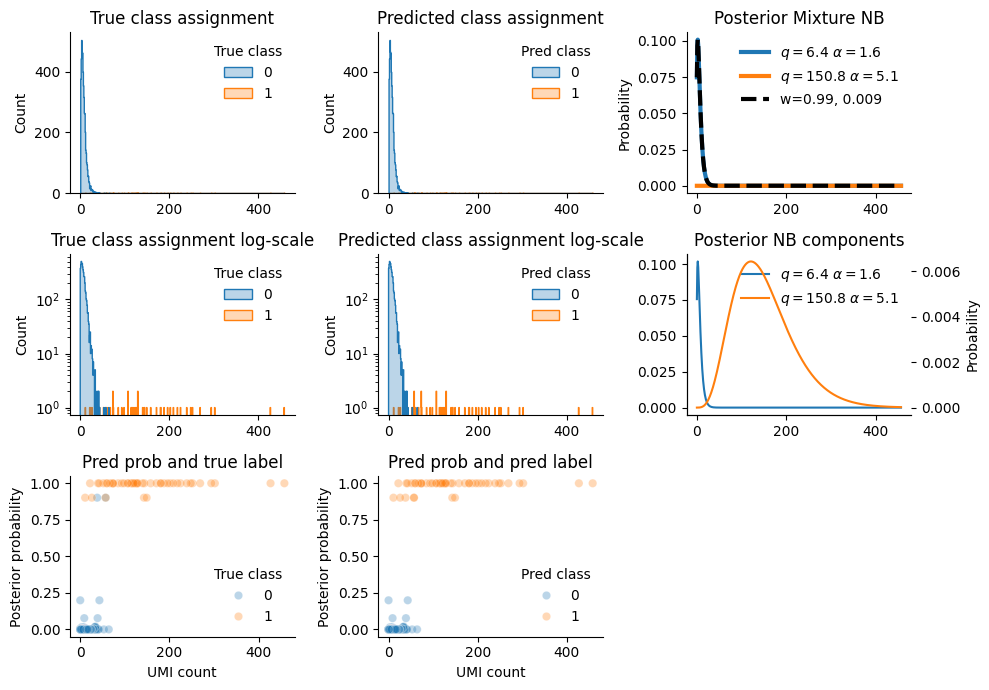

In [6]:
# Plot results
model.plot_results(assignment=assignment, p_pred=p_pred, y_true=y_true, show=True)

In [5]:
# Original results as reported in the paper for comparison
original_results = {'DextraDemixer': [0.907216495, 0.936170213, 0.88, 0.934018965], 
                    'DextraDemixer+neg.': [0.907216495,	0.936170213, 0.88, 0.934018965], 
                    'DextraDemixer+clone': [0.97029703, 0.960784314, 0.98, 0.983597228], 
                    'DextraDemixer+neg.+clone': [0.97029703, 0.960784314, 0.98, 0.983597228]}
original_results = pd.Series(original_results[MODEL_CONFIG], index=['f1', 'precision', 'recall', 'aps'])

print('Results same as original results:', ((original_results - results) < 1e-6).all())

Results same as original results: True
